In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tqdm
from utils import (
    FlowDataset, 
    plot_density,
    plot_each_step,
)
from flow import (
    SimpleAffine, 
    StackSimpleAffine,
    RealNVPNode, 
    RealNVP,
)

In [21]:
# Very simple training loop
def train(model, data, epochs = 100, batch_size = 64):
    train_loader = torch.utils.data.DataLoader(data, batch_size=batch_size)
    optimizer = torch.optim.Adam(model.parameters())
    
    losses = []
    with tqdm.tqdm(range(epochs), unit=' Epoch') as tepoch:
        epoch_loss = 0
        for epoch in tepoch:
            for batch_index, training_sample in enumerate(train_loader):
                log_prob = model.log_probability(training_sample)
                loss = - log_prob.mean(0)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss
            epoch_loss /= len(train_loader)
            losses.append(np.copy(epoch_loss.detach().numpy()))
            tepoch.set_postfix(loss=epoch_loss.detach().numpy())

    return model, losses


In [16]:
data = FlowDataset(num_gaussian=3,num_samples=1000)

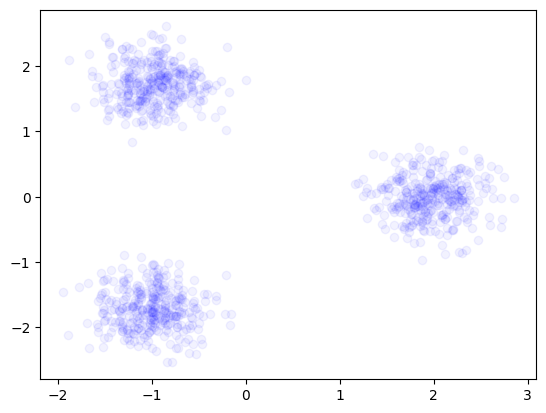

In [17]:
plt.scatter(data[:,0], data[:,1], alpha=.05, c='blue')

# Simple Affine Transform

In [39]:
data = FlowDataset()
model = StackSimpleAffine([SimpleAffine()]*3)
model, loss = train(model, data, epochs= 100)

100%|██████████| 100/100 [00:02<00:00, 37.86 Epoch/s, loss=3.7948174]


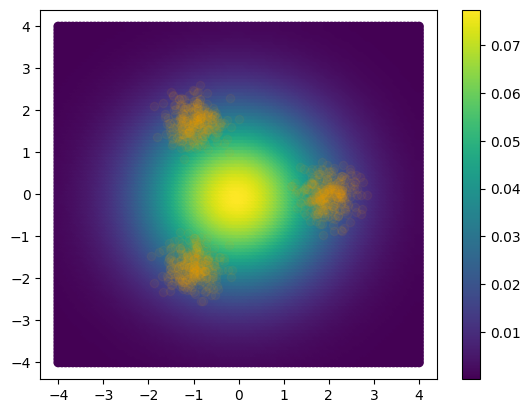

In [40]:
plot_density(model, data)

# RealNVP

In [41]:
torch.manual_seed(2)
np.random.seed(0)

num_layers= 4
masks = torch.nn.functional.one_hot(torch.tensor([i % 2 for i in range(num_layers)])).float()
hidden_size = 32

data = FlowDataset()
NVP_model = RealNVP(masks, hidden_size)
NVP_model, loss = train(NVP_model, data, epochs= 1000)

  0%|          | 0/1000 [00:00<?, ? Epoch/s]

100%|██████████| 1000/1000 [01:33<00:00, 10.69 Epoch/s, loss=1.6758786]


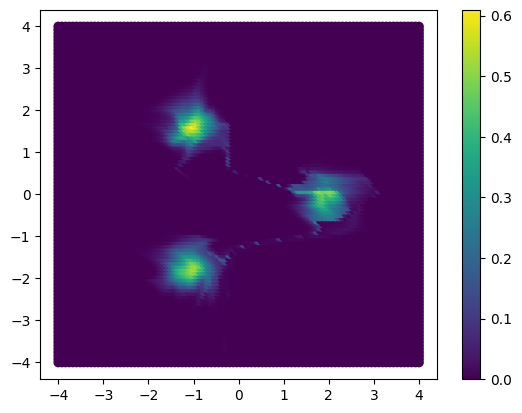

In [42]:
plot_density(NVP_model)

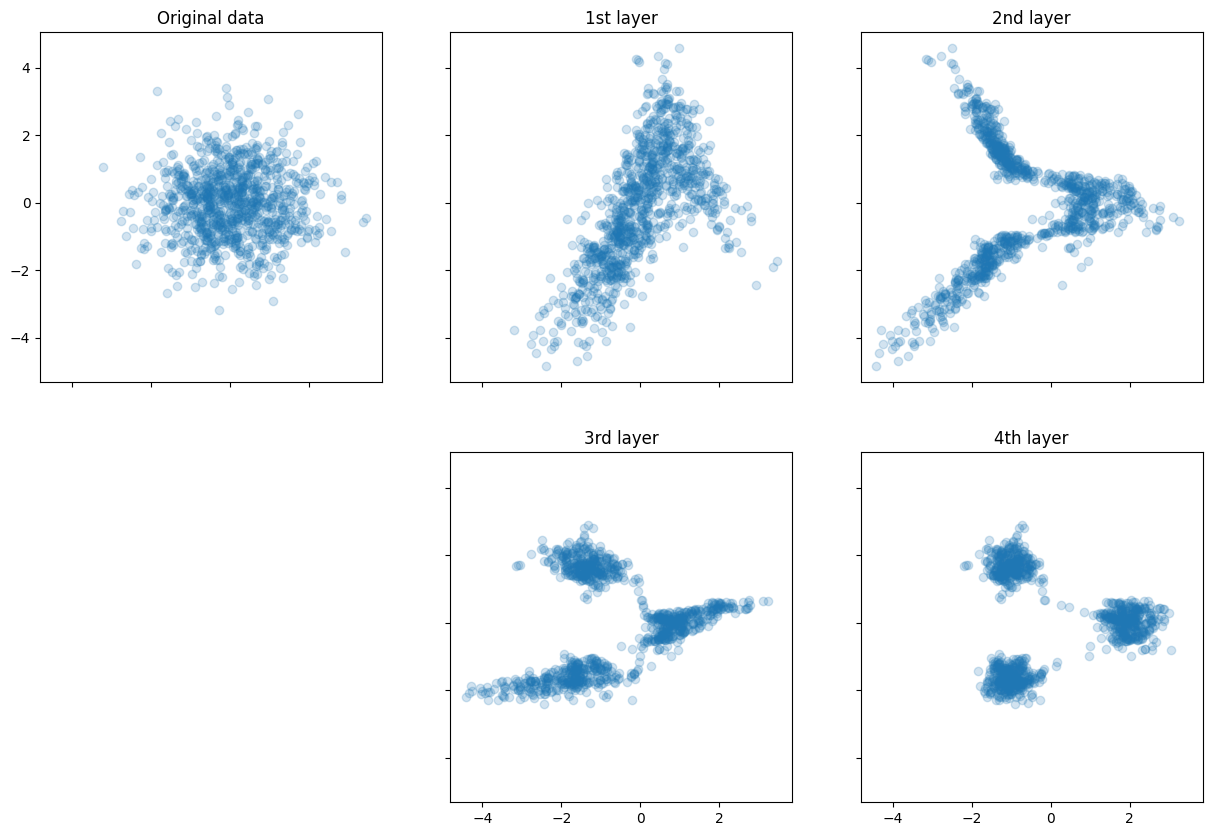

In [43]:
plot_each_step(NVP_model, 1000)

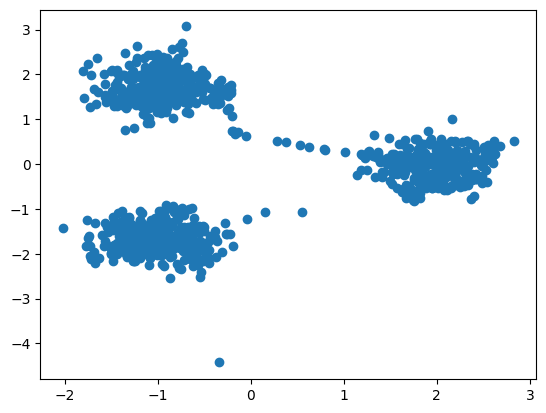

In [58]:
# Resample.
resample = NVP_model.resample(1000)[0].detach().numpy()
plt.scatter(resample[:,0], resample[:,1])